# EEGNet — BCI Competition IV-2a (LOSO)

Cross-subject motor-imagery classification with EEGNet, replacing a CSP + MLP baseline (40% accuracy).

**Pipeline:** GDF loading (MNE) → CAR + 4-38 Hz filter → per-trial normalization → EEGNet (PyTorch) → Leave-One-Subject-Out CV → optional subject-specific fine-tuning.

## 1. Setup & Configuration

In [9]:
import os
import glob
import random
import warnings

import numpy as np
import pandas as pd
import scipy.io
from scipy.signal import welch

import matplotlib.pyplot as plt
import seaborn as sns

import mne

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')
mne.set_log_level('ERROR')
sns.set_theme(style='whitegrid', palette='deep')

In [10]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


CONFIG = {
    'DATA_DIR': 'data/raw',          # root folder, searched recursively
    'LABELS_DIR': 'data/raw',        # true-label .mat files (e.g. true_labels/A0#E.mat), searched recursively
    'SUBJECTS': list(range(1, 10)),
    'CLASS_NAMES': ['Left Hand', 'Right Hand', 'Feet', 'Tongue'],

    # Epoching / filtering
    'TMIN': 0.0,                     # seconds relative to cue onset
    'TMAX': 4.0,
    'L_FREQ': 4.0,
    'H_FREQ': 38.0,
    'TARGET_SFREQ': 128,

    # Training (fast preset: lower EPOCHS/PATIENCE = faster but slightly lower accuracy;
    # for the original higher-accuracy settings use EPOCHS=300, PATIENCE=30, USE_AUGMENTATION=True)
    'BATCH_SIZE': 128,
    'EPOCHS': 42,
    'PATIENCE': 6,
    'LR': 1e-3,
    'WEIGHT_DECAY': 1e-4,
    'LABEL_SMOOTHING': 0.05,
    'USE_AUGMENTATION': False,
    'NOISE_STD': 0.05,
    'MAX_SHIFT': 8,

    # EEGNet hyperparameters
    'F1': 8,
    'D': 2,
    'F2': 16,
    'KERNEL_LENGTH': 64,
    'DROPOUT': 0.5,

    # Fine-tuning (Section 9) — skip this whole section if you're short on time
    'FINETUNE_EPOCHS': 10,
    'FINETUNE_LR_FACTOR': 0.1,
    'CALIBRATION_FRACTION': 0.5,

    'SEED': 42,
    'DEVICE': 'cuda' if torch.cuda.is_available() else 'cpu',
}

set_seed(CONFIG['SEED'])
print(f"Device: {CONFIG['DEVICE']}")

Device: cpu


## 2. Data Loading

BCI IV-2a: 9 subjects x (`A0#T.gdf` train, `A0#E.gdf` eval), 22 EEG + 3 EOG channels, 250 Hz. Cue codes: `769`=left hand, `770`=right hand, `771`=feet, `772`=tongue.



In [11]:
def find_file(filename, root):
    matches = glob.glob(os.path.join(root, '**', filename), recursive=True)
    if not matches:
        raise FileNotFoundError(f"Could not locate '{filename}' under '{root}'")
    return matches[0]


def load_true_labels(mat_path):
    mat = scipy.io.loadmat(mat_path)
    key = 'classlabels' if 'classlabels' in mat else \
        [k for k in mat.keys() if not k.startswith('__')][0]
    return mat[key].squeeze().astype(int) - 1  # -> 0-indexed

In [12]:
# Diagnostic: check whether your files already have labels embedded, or need an external .mat.
_diag_path = find_file(f"A{CONFIG['SUBJECTS'][0]:02d}E.gdf", CONFIG['DATA_DIR'])
_diag_raw = mne.io.read_raw_gdf(_diag_path, preload=False, verbose=False)
_, _diag_event_id = mne.events_from_annotations(_diag_raw, verbose=False)
codes_found = sorted(_diag_event_id.keys())
_class_codes_check = ['769', '770', '771', '772']
print(f"Annotation codes in {os.path.basename(_diag_path)}: {codes_found}")
if all(c in codes_found for c in _class_codes_check):
    print("-> Labels are embedded directly. No .mat files needed; the loader will use them as-is.")
elif '783' in codes_found:
    print("-> Cue is unknown ('783'). The loader will look for an external true_labels .mat file;")
    print("   if none is found for a given file, that session is skipped (see Section 2 loader).")
del _diag_raw, _diag_event_id

Annotation codes in A01E.gdf: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('783')]
-> Cue is unknown ('783'). The loader will look for an external true_labels .mat file;
   if none is found for a given file, that session is skipped (see Section 2 loader).


In [13]:
CLASS_CODES = ['769', '770', '771', '772']  # left, right, feet, tongue

def load_session(gdf_path, labels_dir, cfg):
    raw = mne.io.read_raw_gdf(gdf_path, preload=True, verbose=False)

    eog_chs = [ch for ch in raw.ch_names if 'EOG' in ch.upper()]
    if eog_chs:
        raw.set_channel_types({ch: 'eog' for ch in eog_chs})

    raw.set_eeg_reference('average', projection=False, verbose=False)  # common average reference
    raw.filter(l_freq=cfg['L_FREQ'], h_freq=cfg['H_FREQ'], fir_design='firwin', verbose=False)

    events, event_id = mne.events_from_annotations(raw, verbose=False)
    present = [c for c in CLASS_CODES if c in event_id]

    if len(present) == 4:
        # Labels available directly (training session, or a pre-labeled eval session)
        sel_id = {c: event_id[c] for c in CLASS_CODES}
        epochs = mne.Epochs(raw, events, event_id=sel_id, tmin=cfg['TMIN'], tmax=cfg['TMAX'],
                             baseline=None, preload=True, picks='eeg', verbose=False)
        epochs.resample(cfg['TARGET_SFREQ'], verbose=False)
        code_to_class = {sel_id[c]: i for i, c in enumerate(CLASS_CODES)}
        y = np.array([code_to_class[e] for e in epochs.events[:, -1]], dtype=np.int64)

    elif '783' in event_id:
        # Evaluation session: unknown cue, true labels come from an external .mat file
        sel_id = {'783': event_id['783']}
        epochs = mne.Epochs(raw, events, event_id=sel_id, tmin=cfg['TMIN'], tmax=cfg['TMAX'],
                             baseline=None, preload=True, picks='eeg', verbose=False)
        epochs.resample(cfg['TARGET_SFREQ'], verbose=False)
        label_file = os.path.basename(gdf_path).replace('.gdf', '.mat')
        y = load_true_labels(find_file(label_file, labels_dir))
        assert len(y) == len(epochs), f"Label/epoch count mismatch for {gdf_path}"

    else:
        raise ValueError(f"No recognizable class-cue annotations in {gdf_path}")

    X = epochs.get_data().astype(np.float32)
    return X, y, epochs.ch_names

In [14]:
def load_subject(subject_id, cfg):
    Xs, ys, ch_names_ref = [], [], None
    for session in ('T', 'E'):
        fname = f"A{subject_id:02d}{session}.gdf"
        try:
            fpath = find_file(fname, cfg['DATA_DIR'])
        except FileNotFoundError:
            print(f"  [skip] {fname}: file not found under {cfg['DATA_DIR']}")
            continue
        try:
            X, y, ch_names = load_session(fpath, cfg['LABELS_DIR'], cfg)
        except (FileNotFoundError, ValueError) as e:
            print(f"  [skip] {fname}: {e}")
            continue
        ch_names_ref = ch_names_ref or ch_names
        Xs.append(X)
        ys.append(y)
    if not Xs:
        raise RuntimeError(f"No usable sessions found for subject {subject_id}.")
    return np.concatenate(Xs, axis=0), np.concatenate(ys, axis=0), ch_names_ref

In [15]:
subject_data = {}
CH_NAMES = None

for sid in CONFIG['SUBJECTS']:
    X, y, ch_names = load_subject(sid, CONFIG)
    subject_data[sid] = (X, y)
    CH_NAMES = CH_NAMES or ch_names
    print(f"Subject {sid:02d}: X={X.shape}  class counts={np.bincount(y, minlength=4)}")

CH_COUNT = subject_data[CONFIG['SUBJECTS'][0]][0].shape[1]
N_SAMPLES = subject_data[CONFIG['SUBJECTS'][0]][0].shape[2]
print(f"\nChannels ({CH_COUNT}): {CH_NAMES}")
print(f"Samples per trial: {N_SAMPLES} @ {CONFIG['TARGET_SFREQ']} Hz")

summary = pd.DataFrame(
    {sid: np.bincount(subject_data[sid][1], minlength=4) for sid in CONFIG['SUBJECTS']},
    index=CONFIG['CLASS_NAMES']
).T
summary.index.name = 'Subject'
summary

  [skip] A01E.gdf: Could not locate 'A01E.mat' under 'data/raw'
Subject 01: X=(288, 22, 513)  class counts=[72 72 72 72]
  [skip] A02E.gdf: Could not locate 'A02E.mat' under 'data/raw'
Subject 02: X=(288, 22, 513)  class counts=[72 72 72 72]
  [skip] A03E.gdf: Could not locate 'A03E.mat' under 'data/raw'
Subject 03: X=(288, 22, 513)  class counts=[72 72 72 72]
  [skip] A04E.gdf: Could not locate 'A04E.mat' under 'data/raw'
Subject 04: X=(288, 22, 513)  class counts=[72 72 72 72]
  [skip] A05E.gdf: Could not locate 'A05E.mat' under 'data/raw'
Subject 05: X=(288, 22, 513)  class counts=[72 72 72 72]
  [skip] A06E.gdf: Could not locate 'A06E.mat' under 'data/raw'
Subject 06: X=(288, 22, 513)  class counts=[72 72 72 72]
  [skip] A07E.gdf: Could not locate 'A07E.mat' under 'data/raw'
Subject 07: X=(288, 22, 513)  class counts=[72 72 72 72]
  [skip] A08E.gdf: Could not locate 'A08E.mat' under 'data/raw'
Subject 08: X=(288, 22, 513)  class counts=[72 72 72 72]
  [skip] A09E.gdf: Could not loc

,Left Hand,Right Hand,Feet,Tongue
Subject,,,,
1,72,72,72,72
2,72,72,72,72
3,72,72,72,72
4,72,72,72,72
5,72,72,72,72
6,72,72,72,72
7,72,72,72,72
8,72,72,72,72
9,72,72,72,72


## 3. Exploratory Data Analysis

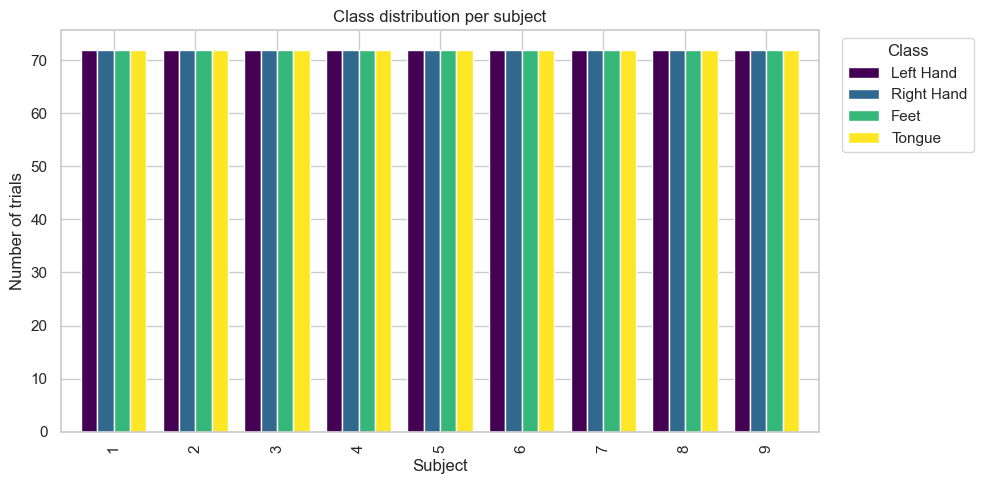

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
summary.plot(kind='bar', ax=ax, colormap='viridis', width=0.8)
ax.set_ylabel('Number of trials')
ax.set_xlabel('Subject')
ax.set_title('Class distribution per subject')
ax.legend(title='Class', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

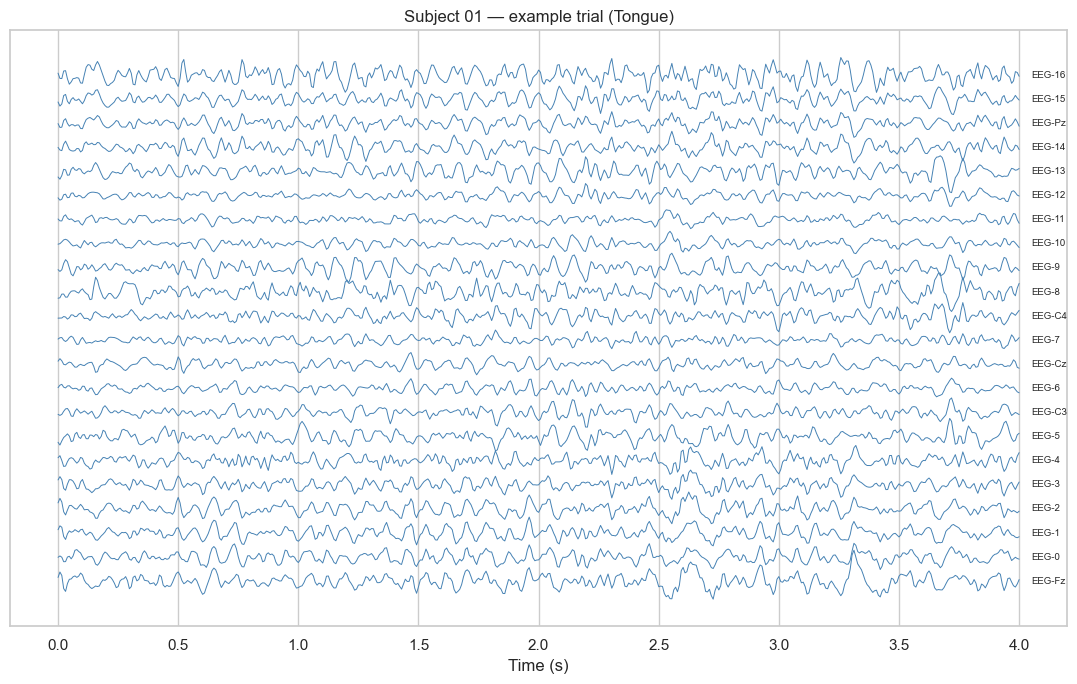

In [17]:
sid_demo = CONFIG['SUBJECTS'][0]
X_demo, y_demo = subject_data[sid_demo]
trial = X_demo[0]
t = np.linspace(CONFIG['TMIN'], CONFIG['TMAX'], trial.shape[1])
offset = 5 * np.median(np.std(trial, axis=1))

fig, ax = plt.subplots(figsize=(11, 7))
for i in range(trial.shape[0]):
    ax.plot(t, trial[i] + i * offset, linewidth=0.7, color='steelblue')
    ax.text(t[-1] + 0.05, i * offset, CH_NAMES[i], fontsize=7, va='center')
ax.set_yticks([])
ax.set_xlabel('Time (s)')
ax.set_title(f"Subject {sid_demo:02d} — example trial ({CONFIG['CLASS_NAMES'][y_demo[0]]})")
plt.tight_layout()
plt.show()

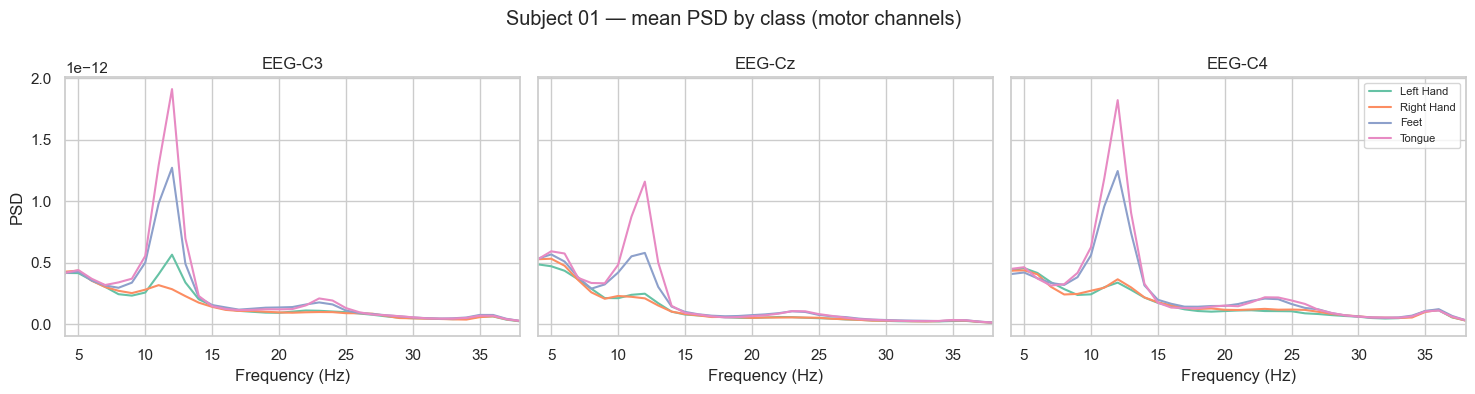

In [18]:
motor_chs = [ch for ch in ['EEG-C3', 'EEG-Cz', 'EEG-C4'] if ch in CH_NAMES]

idxs = [CH_NAMES.index(ch) for ch in motor_chs]
colors = sns.color_palette('Set2', 4)

fig, axes = plt.subplots(1, len(motor_chs), figsize=(5 * len(motor_chs), 4), sharey=True)
if len(motor_chs) == 1:
    axes = [axes]

for ax, ch_idx, ch_name in zip(axes, idxs, motor_chs):
    for c in range(4):
        trials_c = X_demo[y_demo == c, ch_idx, :]
        freqs, psd = welch(trials_c, fs=CONFIG['TARGET_SFREQ'], nperseg=min(128, trials_c.shape[-1]), axis=-1)
        ax.plot(freqs, psd.mean(axis=0), label=CONFIG['CLASS_NAMES'][c], color=colors[c])
    ax.set_title(ch_name)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_xlim(CONFIG['L_FREQ'], CONFIG['H_FREQ'])

axes[0].set_ylabel('PSD')
axes[-1].legend(fontsize=8)
fig.suptitle(f"Subject {sid_demo:02d} — mean PSD by class (motor channels)")
plt.tight_layout()
plt.show()

## 4. Preprocessing

Each trial is z-scored per channel using its own mean/std (not global train statistics). This removes inter-subject amplitude/scale differences — a major source of cross-subject variance in LOSO — without any train/test leakage.

In [19]:
def normalize_trials(X, clip=6.0):
    mean = X.mean(axis=2, keepdims=True)
    std = X.std(axis=2, keepdims=True) + 1e-8
    return np.clip((X - mean) / std, -clip, clip)

In [20]:
class EEGDataset(Dataset):
    def __init__(self, X, y, augment=False, noise_std=0.05, max_shift=8):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
        self.augment = augment
        self.noise_std = noise_std
        self.max_shift = max_shift

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        if self.augment:
            if self.noise_std > 0:
                x = x + torch.randn_like(x) * self.noise_std
            if self.max_shift > 0:
                shift = random.randint(-self.max_shift, self.max_shift)
                x = torch.roll(x, shifts=shift, dims=-1)
        return x.unsqueeze(0), self.y[idx]  # (1, C, T)

## 5. EEGNet

Standard EEGNet (Lawhern et al., 2018): temporal conv → depthwise spatial conv → separable temporal conv, with max-norm weight constraints for regularization. The flatten size is computed dynamically via a dummy forward pass, so the architecture adapts automatically to any channel count / trial length.

In [21]:
class EEGNet(nn.Module):
    def __init__(self, n_classes, n_channels, n_samples, F1=8, D=2, F2=16,
                 kernel_length=64, dropout_rate=0.5):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, kernel_length), padding=(0, kernel_length // 2), bias=False),
            nn.BatchNorm2d(F1),
        )
        self.depthwise = nn.Sequential(
            nn.Conv2d(F1, F1 * D, (n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout_rate),
        )
        self.separable = nn.Sequential(
            nn.Conv2d(F1 * D, F1 * D, (1, 16), padding=(0, 8), groups=F1 * D, bias=False),
            nn.Conv2d(F1 * D, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout_rate),
        )
        self.flatten = nn.Flatten()

        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_samples)
            n_flatten = self._forward_features(dummy).shape[1]
        self.classify = nn.Linear(n_flatten, n_classes)

    def _forward_features(self, x):
        x = self.block1(x)
        x = self.depthwise(x)
        x = self.separable(x)
        return self.flatten(x)

    def forward(self, x):
        return self.classify(self._forward_features(x))


def apply_max_norm_constraint(model, max_norm_dense=0.25, max_norm_depthwise=1.0):
    with torch.no_grad():
        w = model.depthwise[0].weight
        norm = w.view(w.size(0), -1).norm(dim=1).view(-1, 1, 1, 1)
        w.mul_(torch.clamp(norm, max=max_norm_depthwise) / (norm + 1e-8))

        w2 = model.classify.weight
        norm2 = w2.norm(dim=1, keepdim=True)
        w2.mul_(torch.clamp(norm2, max=max_norm_dense) / (norm2 + 1e-8))


# Sanity check
_test_model = EEGNet(
    n_classes=4, n_channels=CH_COUNT, n_samples=N_SAMPLES,
    F1=CONFIG['F1'], D=CONFIG['D'], F2=CONFIG['F2'],
    kernel_length=CONFIG['KERNEL_LENGTH'], dropout_rate=CONFIG['DROPOUT'],
)
_out = _test_model(torch.randn(4, 1, CH_COUNT, N_SAMPLES))
print(f"Output shape: {tuple(_out.shape)}  (expected: (4, 4))")
del _test_model, _out

Output shape: (4, 4)  (expected: (4, 4))


## 6. Training Utilities

In [22]:
class EarlyStopping:
    def __init__(self, patience=30, mode='max'):
        self.patience = patience
        self.mode = mode
        self.best = -np.inf if mode == 'max' else np.inf
        self.counter = 0
        self.best_state = None

    def step(self, metric, model):
        improved = metric > self.best if self.mode == 'max' else metric < self.best
        if improved:
            self.best = metric
            self.counter = 0
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
        return self.counter >= self.patience

    def restore(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def run_epoch(model, loader, criterion, optimizer=None, device='cpu', constrain=True):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    total_loss, correct, n = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.set_grad_enabled(train_mode):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            if train_mode:
                optimizer.zero_grad()

            out = model(xb)
            loss = criterion(out, yb)

            if train_mode:
                loss.backward()
                optimizer.step()
                if constrain:
                    apply_max_norm_constraint(model)

            total_loss += loss.item() * xb.size(0)
            preds = out.argmax(dim=1)
            correct += (preds == yb).sum().item()
            n += xb.size(0)
            all_preds.append(preds.detach().cpu().numpy())
            all_labels.append(yb.detach().cpu().numpy())

    return total_loss / n, correct / n, np.concatenate(all_preds), np.concatenate(all_labels)

## 7. Leave-One-Subject-Out Cross-Validation

For each subject: train on the pooled (T+E) data of the other 8 subjects (85/15 train/val split), test on the held-out subject's full data. A fresh model is trained per fold; the best weights (by validation accuracy) are restored before testing.

In [23]:
os.makedirs('models', exist_ok=True)

results = []
histories = {}
all_test_preds, all_test_labels = [], []
criterion = nn.CrossEntropyLoss(label_smoothing=CONFIG['LABEL_SMOOTHING'])

for test_sid in CONFIG['SUBJECTS']:
    print(f"\n===== Fold: Test Subject {test_sid:02d} =====")
    train_sids = [s for s in CONFIG['SUBJECTS'] if s != test_sid]

    X_pool = np.concatenate([subject_data[s][0] for s in train_sids], axis=0)
    y_pool = np.concatenate([subject_data[s][1] for s in train_sids], axis=0)
    X_test, y_test = subject_data[test_sid]

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_pool, y_pool, test_size=0.15, stratify=y_pool, random_state=CONFIG['SEED'])

    X_tr, X_val, X_test_n = normalize_trials(X_tr), normalize_trials(X_val), normalize_trials(X_test)

    train_loader = DataLoader(EEGDataset(X_tr, y_tr, augment=CONFIG['USE_AUGMENTATION'],
                                          noise_std=CONFIG['NOISE_STD'], max_shift=CONFIG['MAX_SHIFT']),
                               batch_size=CONFIG['BATCH_SIZE'], shuffle=True, drop_last=True)
    val_loader = DataLoader(EEGDataset(X_val, y_val), batch_size=CONFIG['BATCH_SIZE'])
    test_loader = DataLoader(EEGDataset(X_test_n, y_test), batch_size=CONFIG['BATCH_SIZE'])

    model = EEGNet(n_classes=4, n_channels=CH_COUNT, n_samples=N_SAMPLES,
                    F1=CONFIG['F1'], D=CONFIG['D'], F2=CONFIG['F2'],
                    kernel_length=CONFIG['KERNEL_LENGTH'], dropout_rate=CONFIG['DROPOUT']).to(CONFIG['DEVICE'])

    optimizer = optim.Adam(model.parameters(), lr=CONFIG['LR'], weight_decay=CONFIG['WEIGHT_DECAY'])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10)
    stopper = EarlyStopping(patience=CONFIG['PATIENCE'], mode='max')

    hist = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    for epoch in range(CONFIG['EPOCHS']):
        tr_loss, tr_acc, _, _ = run_epoch(model, train_loader, criterion, optimizer, CONFIG['DEVICE'])
        val_loss, val_acc, _, _ = run_epoch(model, val_loader, criterion, None, CONFIG['DEVICE'])
        scheduler.step(val_acc)

        hist['train_loss'].append(tr_loss); hist['val_loss'].append(val_loss)
        hist['train_acc'].append(tr_acc); hist['val_acc'].append(val_acc)

        if (epoch + 1) % 20 == 0:
            print(f"  epoch {epoch+1:3d} | train {tr_loss:.3f}/{tr_acc:.3f} | val {val_loss:.3f}/{val_acc:.3f}")

        if stopper.step(val_acc, model):
            print(f"  early stop @ epoch {epoch+1} (best val_acc={stopper.best:.3f})")
            break

    stopper.restore(model)
    torch.save(model.state_dict(), f"models/eegnet_loso_S{test_sid:02d}.pt")

    _, test_acc, test_preds, test_labels = run_epoch(model, test_loader, criterion, None, CONFIG['DEVICE'])
    kappa = cohen_kappa_score(test_labels, test_preds)
    report = classification_report(test_labels, test_preds, target_names=CONFIG['CLASS_NAMES'],
                                    output_dict=True, zero_division=0)

    print(f"  >> test accuracy={test_acc:.4f}  kappa={kappa:.4f}")

    results.append({
        'subject': test_sid, 'accuracy': test_acc, 'kappa': kappa,
        **{f'f1_{c}': report[c]['f1-score'] for c in CONFIG['CLASS_NAMES']},
    })
    histories[test_sid] = hist
    all_test_preds.append(test_preds)
    all_test_labels.append(test_labels)

all_test_preds = np.concatenate(all_test_preds)
all_test_labels = np.concatenate(all_test_labels)


===== Fold: Test Subject 01 =====
  epoch  20 | train 1.219/0.454 | val 1.196/0.494
  epoch  40 | train 1.128/0.519 | val 1.095/0.584
  >> test accuracy=0.6597  kappa=0.5463

===== Fold: Test Subject 02 =====
  epoch  20 | train 1.244/0.442 | val 1.222/0.488
  epoch  40 | train 1.117/0.548 | val 1.055/0.604
  >> test accuracy=0.2986  kappa=0.0648

===== Fold: Test Subject 03 =====
  epoch  20 | train 1.232/0.451 | val 1.180/0.572
  early stop @ epoch 26 (best val_acc=0.572)
  >> test accuracy=0.5868  kappa=0.4491

===== Fold: Test Subject 04 =====
  epoch  20 | train 1.179/0.486 | val 1.131/0.561
  early stop @ epoch 37 (best val_acc=0.618)
  >> test accuracy=0.4028  kappa=0.2037

===== Fold: Test Subject 05 =====
  epoch  20 | train 1.144/0.506 | val 1.091/0.546
  epoch  40 | train 1.053/0.576 | val 0.987/0.647
  early stop @ epoch 42 (best val_acc=0.653)
  >> test accuracy=0.2569  kappa=0.0093

===== Fold: Test Subject 06 =====
  epoch  20 | train 1.187/0.470 | val 1.133/0.543
  epo

## 8. Results

In [24]:
results_df = pd.DataFrame(results).set_index('subject')
summary_stats = results_df[['accuracy', 'kappa']].agg(['mean', 'std'])

print(results_df.round(4))
print("\nSummary:")
print(summary_stats.round(4))

results_df.to_csv('loso_results.csv')

         accuracy   kappa  f1_Left Hand  f1_Right Hand  f1_Feet  f1_Tongue
subject                                                                   
1          0.6597  0.5463        0.6545         0.7591   0.5310     0.6708
2          0.2986  0.0648        0.4370         0.2182   0.0698     0.2182
3          0.5868  0.4491        0.6405         0.6992   0.2353     0.6566
4          0.4028  0.2037        0.3548         0.5730   0.3626     0.2174
5          0.2569  0.0093        0.4035         0.1111   0.0000     0.0000
6          0.3507  0.1343        0.2093         0.4444   0.1579     0.4393
7          0.3472  0.1296        0.4541         0.4084   0.0519     0.1772
8          0.4965  0.3287        0.6129         0.5689   0.2308     0.4715
9          0.5521  0.4028        0.6618         0.5135   0.3252     0.6627

Summary:
      accuracy   kappa
mean    0.4390  0.2521
std     0.1401  0.1868


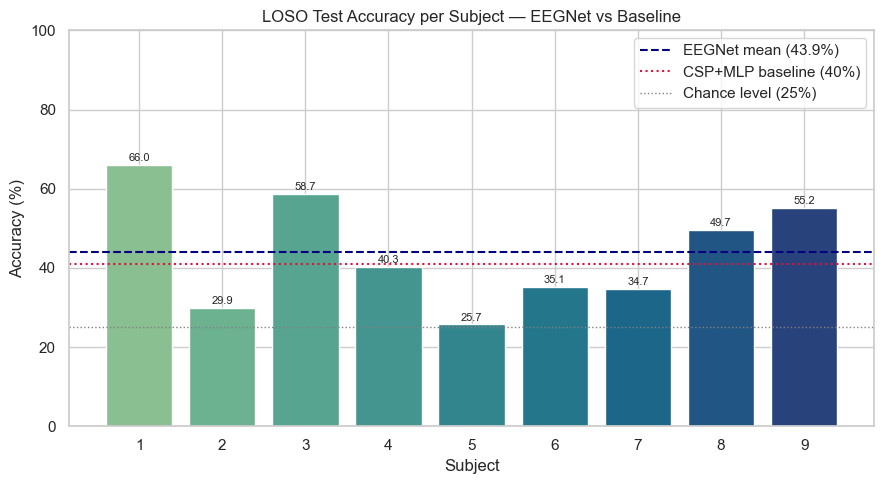

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(results_df.index.astype(str), results_df['accuracy'] * 100,
              color=sns.color_palette('crest', len(results_df)))

mean_acc = results_df['accuracy'].mean() * 100
ax.axhline(mean_acc, color='navy', linestyle='--', label=f'EEGNet mean ({mean_acc:.1f}%)')
ax.axhline(40, color='crimson', linestyle=':', label='CSP+MLP baseline (40%)')
ax.axhline(25, color='gray', linestyle=':', linewidth=1, label='Chance level (25%)')

for bar, acc in zip(bars, results_df['accuracy'] * 100):
    ax.text(bar.get_x() + bar.get_width() / 2, acc + 1, f"{acc:.1f}", ha='center', fontsize=8)

ax.set_xlabel('Subject'); ax.set_ylabel('Accuracy (%)'); ax.set_ylim(0, 100)
ax.set_title('LOSO Test Accuracy per Subject — EEGNet vs Baseline')
ax.legend()
plt.tight_layout()
plt.show()

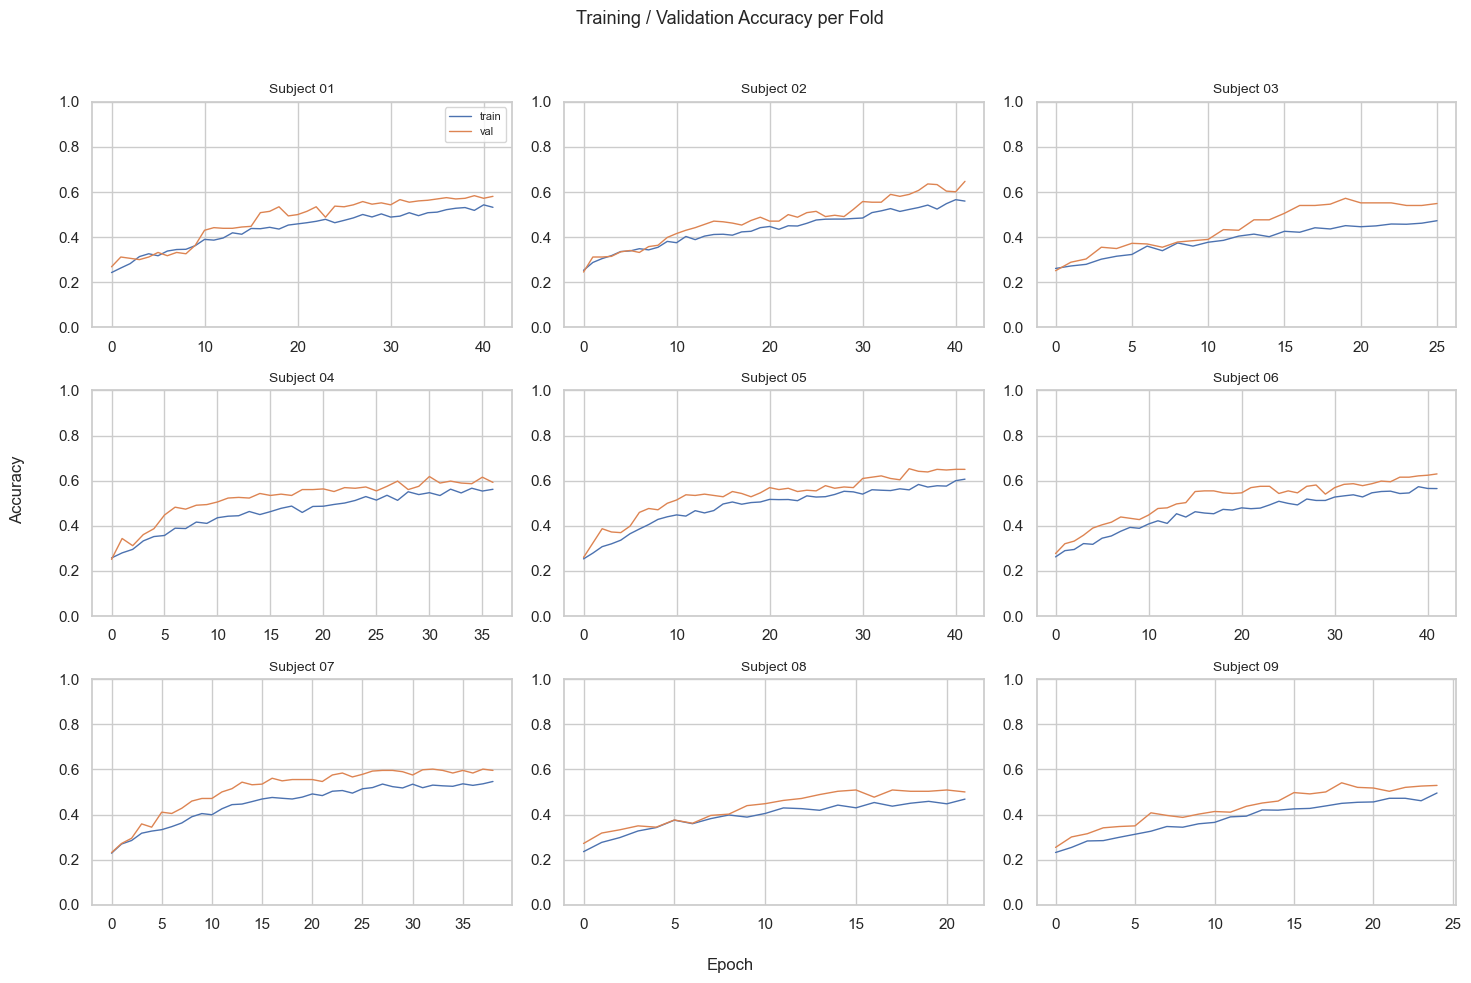

In [27]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, sid in zip(axes.flat, CONFIG['SUBJECTS']):
    h = histories[sid]
    ax.plot(h['train_acc'], label='train', linewidth=1)
    ax.plot(h['val_acc'], label='val', linewidth=1)
    ax.set_title(f"Subject {sid:02d}", fontsize=10)
    ax.set_ylim(0, 1)
axes[0, 0].legend(fontsize=8)
fig.suptitle('Training / Validation Accuracy per Fold', fontsize=13)
fig.text(0.5, 0.02, 'Epoch', ha='center')
fig.text(0.02, 0.5, 'Accuracy', va='center', rotation='vertical')
plt.tight_layout(rect=[0.04, 0.04, 1, 0.96])
plt.show()

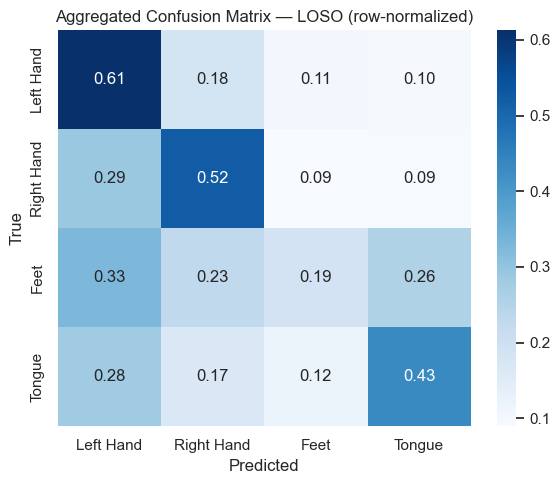

In [28]:
cm = confusion_matrix(all_test_labels, all_test_preds, normalize='true')
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CONFIG['CLASS_NAMES'], yticklabels=CONFIG['CLASS_NAMES'], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Aggregated Confusion Matrix — LOSO (row-normalized)')
plt.tight_layout()
plt.show()

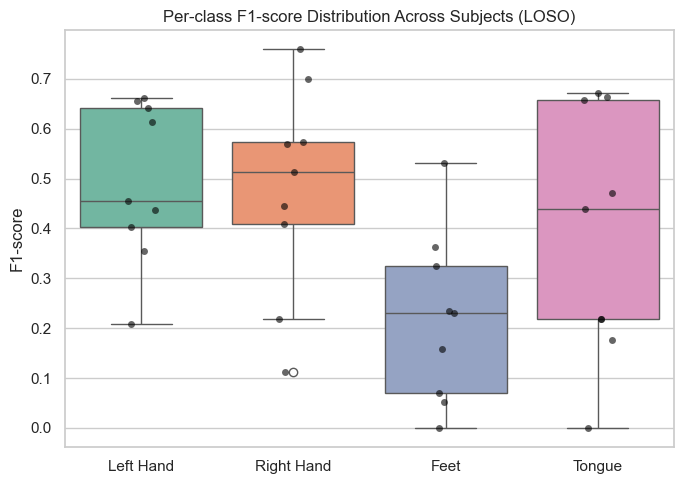

In [29]:
f1_cols = [f'f1_{c}' for c in CONFIG['CLASS_NAMES']]
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=results_df[f1_cols], palette='Set2', ax=ax)
sns.stripplot(data=results_df[f1_cols], color='black', size=5, alpha=0.6, ax=ax)
ax.set_xticklabels(CONFIG['CLASS_NAMES'])
ax.set_ylabel('F1-score')
ax.set_title('Per-class F1-score Distribution Across Subjects (LOSO)')
plt.tight_layout()
plt.show()

## 9. Optional: Subject-Specific Fine-Tuning

Pure LOSO simulates a zero-calibration BCI. Briefly fine-tuning each LOSO model on a slice of the target subject's own data (few-shot calibration) typically raises accuracy further — a realistic and common deployment scenario.

In [30]:
finetune_results = []

for test_sid in CONFIG['SUBJECTS']:
    model = EEGNet(n_classes=4, n_channels=CH_COUNT, n_samples=N_SAMPLES,
                    F1=CONFIG['F1'], D=CONFIG['D'], F2=CONFIG['F2'],
                    kernel_length=CONFIG['KERNEL_LENGTH'], dropout_rate=CONFIG['DROPOUT']).to(CONFIG['DEVICE'])
    model.load_state_dict(torch.load(f"models/eegnet_loso_S{test_sid:02d}.pt", map_location=CONFIG['DEVICE']))

    X_sub, y_sub = subject_data[test_sid]
    X_cal, X_eval, y_cal, y_eval = train_test_split(
        X_sub, y_sub, test_size=1 - CONFIG['CALIBRATION_FRACTION'], stratify=y_sub, random_state=CONFIG['SEED'])

    X_cal, X_eval_n = normalize_trials(X_cal), normalize_trials(X_eval)
    cal_loader = DataLoader(EEGDataset(X_cal, y_cal, augment=True,
                                        noise_std=CONFIG['NOISE_STD'], max_shift=CONFIG['MAX_SHIFT']),
                             batch_size=CONFIG['BATCH_SIZE'], shuffle=True)
    eval_loader = DataLoader(EEGDataset(X_eval_n, y_eval), batch_size=CONFIG['BATCH_SIZE'])

    ft_optimizer = optim.Adam(model.parameters(), lr=CONFIG['LR'] * CONFIG['FINETUNE_LR_FACTOR'],
                               weight_decay=CONFIG['WEIGHT_DECAY'])
    for _ in range(CONFIG['FINETUNE_EPOCHS']):
        run_epoch(model, cal_loader, criterion, ft_optimizer, CONFIG['DEVICE'])

    _, ft_acc, ft_preds, ft_labels = run_epoch(model, eval_loader, criterion, None, CONFIG['DEVICE'])
    ft_kappa = cohen_kappa_score(ft_labels, ft_preds)
    finetune_results.append({'subject': test_sid, 'accuracy': ft_acc, 'kappa': ft_kappa})
    print(f"Subject {test_sid:02d}: fine-tuned accuracy={ft_acc:.4f}  kappa={ft_kappa:.4f}")

ft_df = pd.DataFrame(finetune_results).set_index('subject')
print(f"\nMean fine-tuned accuracy: {ft_df['accuracy'].mean():.4f} "
      f"(zero-shot LOSO: {results_df['accuracy'].mean():.4f})")

Subject 01: fine-tuned accuracy=0.6736  kappa=0.5648
Subject 02: fine-tuned accuracy=0.3194  kappa=0.0926
Subject 03: fine-tuned accuracy=0.6597  kappa=0.5463
Subject 04: fine-tuned accuracy=0.4236  kappa=0.2315
Subject 05: fine-tuned accuracy=0.2569  kappa=0.0093
Subject 06: fine-tuned accuracy=0.4236  kappa=0.2315
Subject 07: fine-tuned accuracy=0.3958  kappa=0.1944
Subject 08: fine-tuned accuracy=0.5694  kappa=0.4259
Subject 09: fine-tuned accuracy=0.5625  kappa=0.4167

Mean fine-tuned accuracy: 0.4761 (zero-shot LOSO: 0.4390)


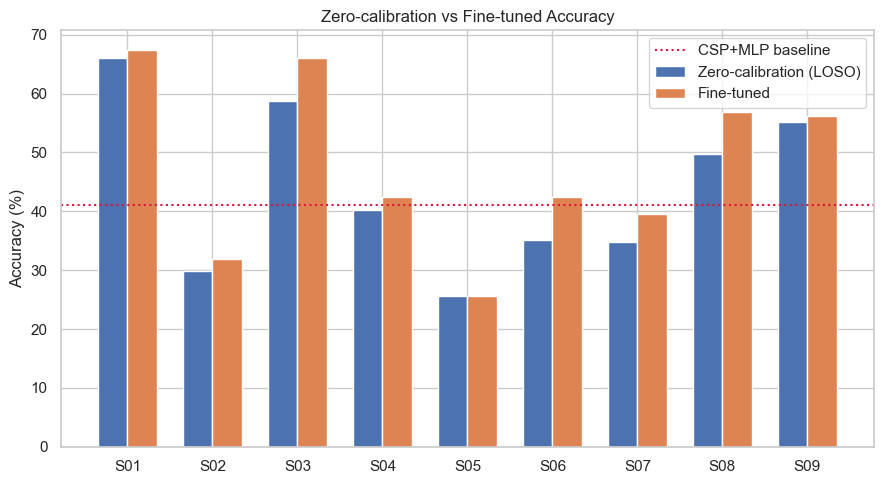

In [ ]:
x = np.arange(len(CONFIG['SUBJECTS']))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, results_df['accuracy'] * 100, width, label='Zero-calibration (LOSO)', color='#4C72B0')
ax.bar(x + width/2, ft_df['accuracy'] * 100, width, label='Fine-tuned', color='#DD8452')
ax.axhline(40, color='crimson', linestyle=':', label='CSP+MLP baseline')

ax.set_xticks(x); ax.set_xticklabels([f"S{s:02d}" for s in CONFIG['SUBJECTS']])
ax.set_ylabel('Accuracy (%)')
ax.set_title('Zero-calibration vs Fine-tuned Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Final Test Performance Summary

FINAL LOSO TEST SUMMARY
Mean accuracy across all 9 held-out subjects : 0.439 +/- 0.140
Mean Cohen's kappa                            : 0.252
CSP + MLP baseline                            : 0.400
Chance level (4 balanced classes)             : 0.250
Improvement over baseline                     : +0.039


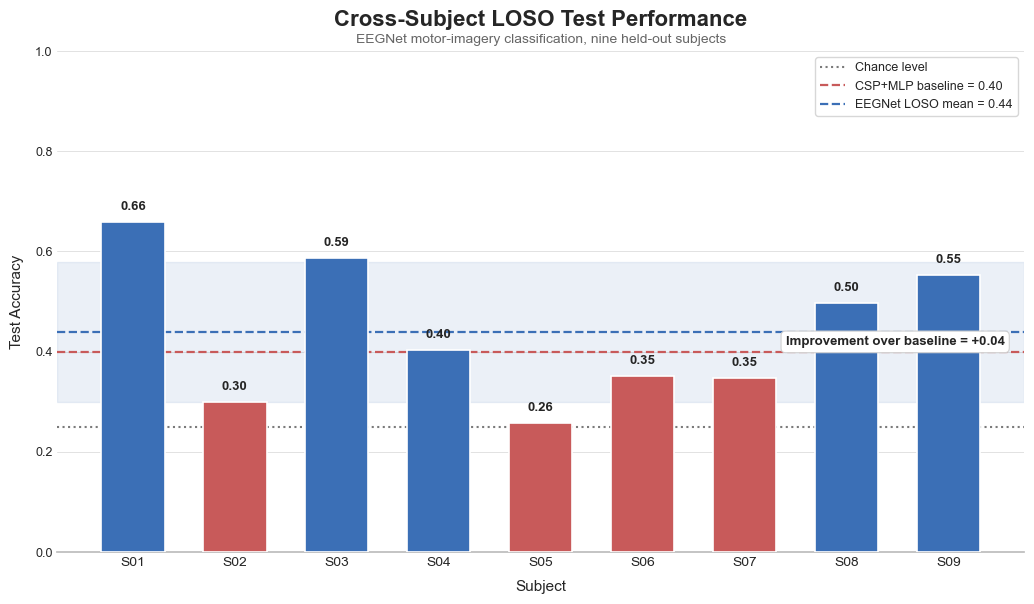

In [33]:
FIGURES_DIR = 'figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

mean_acc = results_df['accuracy'].mean()
std_acc = results_df['accuracy'].std()
mean_kappa = results_df['kappa'].mean()
baseline_acc = 0.40
chance_acc = 0.25
improvement = mean_acc - baseline_acc

print("=" * 60)
print("FINAL LOSO TEST SUMMARY")
print("=" * 60)
print(f"Mean accuracy across all 9 held-out subjects : {mean_acc:.3f} +/- {std_acc:.3f}")
print(f"Mean Cohen's kappa                            : {mean_kappa:.3f}")
print(f"CSP + MLP baseline                            : {baseline_acc:.3f}")
print(f"Chance level (4 balanced classes)             : {chance_acc:.3f}")
print(f"Improvement over baseline                     : {improvement:+.3f}")
print("=" * 60)

# ---- Publication-style summary chart ----
fig, ax = plt.subplots(figsize=(10.5, 6.2))

subjects = [f"S{s:02d}" for s in results_df.index]
accuracies = results_df['accuracy'].values

above_color = '#3B6FB6'
below_color = '#C85A5A'
chance_color = '#7A7A7A'
text_color = '#252525'

bar_colors = [above_color if a >= baseline_acc else below_color for a in accuracies]

bars = ax.bar(
    subjects, accuracies, width=0.62,
    color=bar_colors, edgecolor='white', linewidth=1.2, zorder=3
)

# Variability band across subjects
ax.axhspan(mean_acc - std_acc, mean_acc + std_acc, color=above_color, alpha=0.10, zorder=1)

# Reference lines
ax.axhline(chance_acc, color=chance_color, linestyle=':', linewidth=1.5,
           label='Chance level', zorder=2)
ax.axhline(baseline_acc, color=below_color, linestyle='--', linewidth=1.6,
           label=f'CSP+MLP baseline = {baseline_acc:.2f}', zorder=2)
ax.axhline(mean_acc, color=above_color, linestyle='--', linewidth=1.6,
           label=f'EEGNet LOSO mean = {mean_acc:.2f}', zorder=2)

# Value labels
for bar, value in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.018, f'{value:.2f}',
            ha='center', va='bottom', fontsize=9.5, fontweight='bold', color=text_color)

# Improvement annotation
ax.annotate(
    f'Improvement over baseline = {improvement:+.2f}',
    xy=(0.98, (mean_acc + baseline_acc) / 2),
    xycoords=('axes fraction', 'data'),
    ha='right', va='center', fontsize=9.5, fontweight='bold', color=text_color,
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#D0D0D0', linewidth=0.8)
)

# Titles
ax.set_title('Cross-Subject LOSO Test Performance', fontsize=16, fontweight='bold', pad=18)
ax.text(0.5, 1.01, 'EEGNet motor-imagery classification, nine held-out subjects',
        transform=ax.transAxes, ha='center', va='bottom', fontsize=10, color='#666666')

ax.set_xlabel('Subject', fontsize=11, labelpad=8)
ax.set_ylabel('Test Accuracy', fontsize=11, labelpad=8)
ax.set_ylim(0, 1.0)

ax.grid(axis='y', linestyle='-', linewidth=0.7, color='#E2E2E2', zorder=0)
ax.grid(axis='x', visible=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#BDBDBD')

ax.tick_params(axis='x', length=0, labelsize=10)
ax.tick_params(axis='y', length=0, labelsize=9)

ax.legend(loc='upper right', fontsize=9, frameon=True, fancybox=True, framealpha=0.95, edgecolor='#D5D5D5')

plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/final_loso_test_summary.png', dpi=400, bbox_inches='tight', facecolor='white')
plt.show()